In [2]:
import pandas as pd

file_path = r'C:/DS_mainproject/portfolio_prjct/PORTFOLIO_PROJECT/data/raw/RELIANCE.NS.csv'

# Skip first 2 rows (adjust if your CSV has more metadata)
df = pd.read_csv(file_path, skiprows=2)

# Assign correct column names (needed because pandas used wrong header)
df.columns = ['Date','Open','High','Low','Close','Volume']

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Optional: set Date as index
df.set_index('Date', inplace=True)

# Drop any empty rows
df = df.dropna(subset=['Open'])

# Print first rows
print(df.head())
print(df.info())


                  Open        High         Low       Close    Volume
Date                                                                
2015-01-01  189.999832  190.877186  189.090381  189.657461   2963643
2015-01-02  189.496933  191.743813  189.229456  190.042601   7331366
2015-01-05  187.421249  190.641775  187.046767  189.379239  10103941
2015-01-06  178.915237  186.811392  178.037884  186.169433  18627980
2015-01-07  182.809814  183.772761  179.107830  179.129229  20720312
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2221 entries, 2015-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2221 non-null   float64
 1   High    2221 non-null   float64
 2   Low     2221 non-null   float64
 3   Close   2221 non-null   float64
 4   Volume  2221 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 104.1 KB
None


In [3]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [4]:
df = df.dropna(subset=['Open'])  # or subset=['Date']


In [5]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-01,189.999832,190.877186,189.090381,189.657461,2963643
2015-01-02,189.496933,191.743813,189.229456,190.042601,7331366
2015-01-05,187.421249,190.641775,187.046767,189.379239,10103941
2015-01-06,178.915237,186.811392,178.037884,186.169433,18627980
2015-01-07,182.809814,183.772761,179.107830,179.129229,20720312


In [6]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [7]:
#check for missing values
print(df.isnull().sum())


Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [8]:
#check for datatype
print(df.dtypes)




Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


In [9]:
#remove duplicate dates if any
print(df.index.duplicated().sum())

0


In [10]:
#sort by date
df=df.sort_index()
print(df)



                   Open         High          Low        Close    Volume
Date                                                                    
2015-01-01   189.999832   190.877186   189.090381   189.657461   2963643
2015-01-02   189.496933   191.743813   189.229456   190.042601   7331366
2015-01-05   187.421249   190.641775   187.046767   189.379239  10103941
2015-01-06   178.915237   186.811392   178.037884   186.169433  18627980
2015-01-07   182.809814   183.772761   179.107830   179.129229  20720312
...                 ...          ...          ...          ...       ...
2023-12-22  1273.102173  1280.968874  1264.466020  1270.397218  16541784
2023-12-26  1279.554443  1286.453333  1271.935784  1274.566338   7465664
2023-12-27  1283.922119  1290.399082  1277.097630  1281.514887   9204156
2023-12-28  1293.203369  1296.404650  1283.922089  1285.386228  12302636
2023-12-29  1282.979126  1297.397435  1280.174930  1295.958136  10864584

[2221 rows x 5 columns]


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2221 entries, 2015-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2221 non-null   float64
 1   High    2221 non-null   float64
 2   Low     2221 non-null   float64
 3   Close   2221 non-null   float64
 4   Volume  2221 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 168.6 KB
None


In [12]:
print(df.describe())

              Open         High          Low        Close        Volume
count  2221.000000  2221.000000  2221.000000  2221.000000  2.221000e+03
mean    654.967930   662.343850   648.140287   655.455241  1.900301e+07
std     370.662887   374.317948   367.263495   370.971810  1.399048e+07
min     173.490677   174.977893   170.430652   174.742513  1.705656e+06
25%     286.076813   290.777012   284.433393   287.314856  1.102748e+07
50%     569.417725   576.243492   564.201640   570.484949  1.498274e+07
75%    1054.023438  1068.658620  1039.196300  1051.960380  2.161084e+07
max    1297.295044  1303.754522  1283.922089  1299.582709  1.426834e+08


In [13]:
# finding :
# 1.
# Min = 174,Max = 1299
# That is a very large difference in minimum and maximum.The stock did not stay around one fixed level,It moved from very low value to very high value.
# This shows:
# There is long-term upward movement
# Price level changes significantly over years
# That indicates trend exists.
# 2.
# Std = 371,Mean = 655
# Standard deviation is more than half of the mean.
# That means:
# Prices are widely spread,Large fluctuations exist,Market is not stable
# This indicates:
# Strong volatility2.
# 3.
# The quartile values (25% = 287, 50% = 570, 75% = 1051) are widely spaced, which shows that the stock price has moved significantly over different periods 
# instead of staying around a stable level. This indicates that in earlier years the price was much lower, and in later years it increased substantially.
# Since the average price level changes over time rather than remaining constant, the market behavior is not stable. This changing mean and distribution 
# over time is what we call a non-stationary market.

    

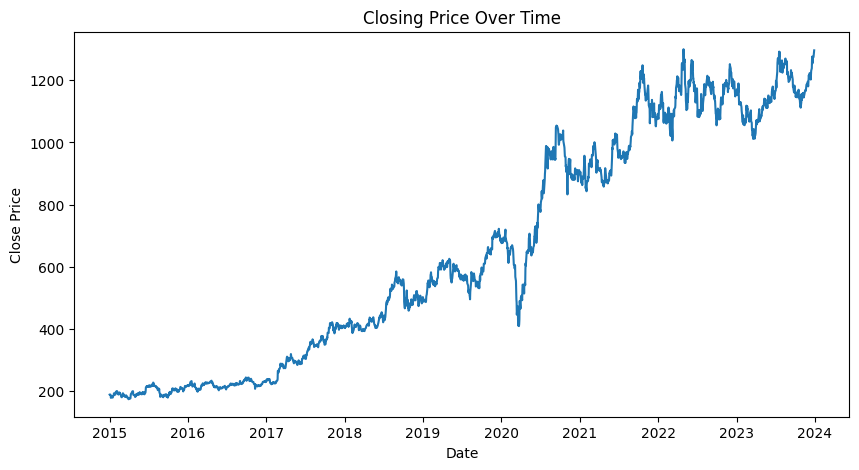

In [14]:
#start eda
#closing price trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


In [15]:
#The stock shows a strong upward trend from 2015 to 2024.


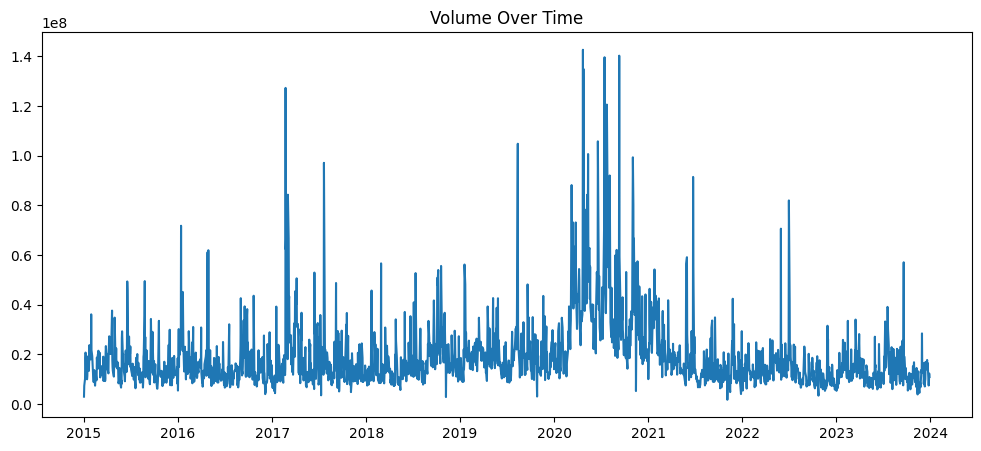

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Volume'])
plt.title("Volume Over Time")
plt.show()


In [17]:
# The volume trend shows significant fluctuations with large spikes during certain periods, particularly around 2020. 
# This indicates increased investor activity during high-uncertainty events. Since trading volume reflects market participation 
# and behavioral reactions, it provides additional information beyond price movements. The variability in volume further confirms
# that the market is dynamic and influenced by external events, supporting the need for advanced deep learning models capable of 
# capturing such changing patterns.

<Axes: >

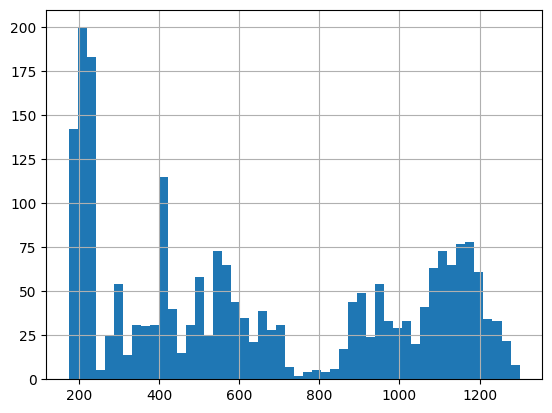

In [18]:
df['Close'].hist(bins=50)


In [19]:
#X-axis → Closing price range
#Y-axis → Number of days price stayed in that range

<Axes: >

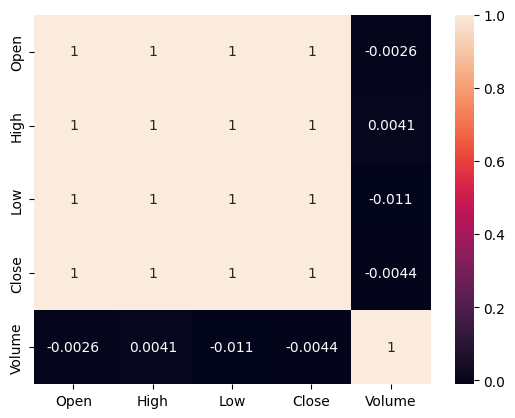

In [20]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)


In [21]:
# All price columns are highly related
# Volume does not strongly affect price
# Daily return is mostly independent
# No strong negative correlation present

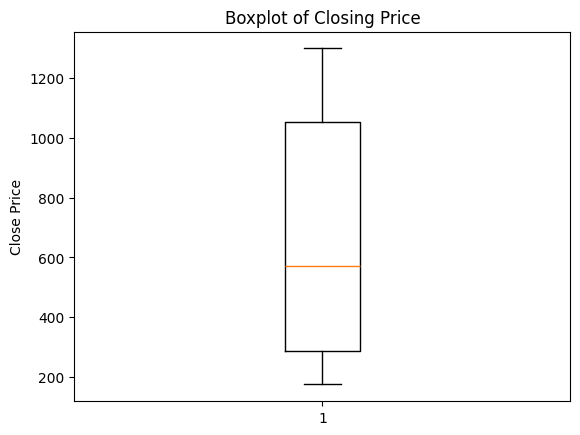

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df['Close'])
plt.title("Boxplot of Closing Price")
plt.ylabel("Close Price")
plt.show()


In [23]:
df['Daily_Return'] = df['Close'].pct_change()

print(df['Daily_Return'].describe())


count    2220.000000
mean        0.001025
std         0.017875
min        -0.106487
25%        -0.009071
50%         0.000448
75%         0.010176
max         0.136958
Name: Daily_Return, dtype: float64


In [24]:
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()


In [25]:
df['Volatility_7'] = df['Daily_Return'].rolling(window=7).std()
df['Volatility_14'] = df['Daily_Return'].rolling(window=14).std()


In [26]:
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))


In [27]:
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = ema12 - ema26
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

df['MACD_Histogram'] = df['MACD'] - df['Signal_Line']


In [28]:
print(df)

                   Open         High          Low        Close    Volume  \
Date                                                                       
2015-01-01   189.999832   190.877186   189.090381   189.657461   2963643   
2015-01-02   189.496933   191.743813   189.229456   190.042601   7331366   
2015-01-05   187.421249   190.641775   187.046767   189.379239  10103941   
2015-01-06   178.915237   186.811392   178.037884   186.169433  18627980   
2015-01-07   182.809814   183.772761   179.107830   179.129229  20720312   
...                 ...          ...          ...          ...       ...   
2023-12-22  1273.102173  1280.968874  1264.466020  1270.397218  16541784   
2023-12-26  1279.554443  1286.453333  1271.935784  1274.566338   7465664   
2023-12-27  1283.922119  1290.399082  1277.097630  1281.514887   9204156   
2023-12-28  1293.203369  1296.404650  1283.922089  1285.386228  12302636   
2023-12-29  1282.979126  1297.397435  1280.174930  1295.958136  10864584   

           

In [30]:
df.shape


(2221, 14)